# 03 — MIDAS (Weekly, EXOG + Macro + Sentiment)

Mixed-Data Sampling regression for **weekly** silver log-returns. Aggregates the
daily target to W-FRI to match the other weekly notebooks (`04_random_forest`,
`05_xgboost`, `06_lstm`) so results are directly comparable.

**Path B alignment** (see `CLAUDE.md` §6 for context):

- Target: weekly silver log-return (Friday-to-Friday), same `train.csv`/`val.csv`/`test.csv`
  split as the other weekly notebooks.
- `EXOG` base = 3 silver autocorrelation lags + 6 cross-asset weekly lagged returns
  (gold, USD, copper, S&P500, VIX, oil). Identical to RF/XGBoost.
- **MIDAS-native contribution**: monthly macro variables (CPI, fed funds, industrial
  production, real rates) enter through **Beta-weighted lag polynomials** —
  3 monthly lags per variable, weights driven by 2 shape parameters $(\theta_1,\theta_2)$.
  This is what makes the model a MIDAS rather than just an ADL.
- Variant ladder: `EXOG → EXOG+Macro → EXOG+Reddit → EXOG+News → EXOG+Reddit+News → EXOG+Macro+Sentiment`.
- **Walk-forward evaluation**: test-period forecasts use an expanding window,
  re-fitting every 4 weeks — matching the RF/XGB retraining cadence.
- Naïve $y_{t-1}$ baseline, Diebold-Mariano vs `EXOG`, period breakdown, 2026 zoom — all
  matching the other weekly notebooks via the shared `eval_utils` conventions.


## What is MIDAS, intuitively?

MIDAS (**Mi**xed-**Da**ta **S**ampling) is a regression framework for situations
where your target and predictors are observed at **different sampling frequencies**.

**Our situation:** weekly silver returns + monthly macro data (CPI, fed funds,
industrial production, real rates). The naïve options would be:

1. **Forward-fill the monthly data to weekly** — what `02_features.ipynb` does
   for the daily feature matrix. Each week inside a given month sees the same
   macro value, which means three out of four weeks get a stale repeat of the
   prior month's reading — treated as if it were fresh information.
2. **Aggregate the target down to monthly** — would lose 75% of the data
   (175 weekly test obs → ~44 monthly obs) and destroy the high-frequency
   variation we actually want to predict.

MIDAS does neither. It keeps the **target at the high frequency** (weekly) and
feeds in the **last K monthly observations** of each macro variable directly,
combining them via a **weight polynomial** that the model learns. This is more
honest about the timing of macro releases and avoids the loss of information
from aggregation (see Ghysels, Santa-Clara & Valkanov 2004; Andreou, Ghysels &
Kourtellos 2013; Foroni & Marcellino survey 2014).

---

### The basic MIDAS equation

For a single high-frequency regressor:

$$y_t^L \;=\; \alpha \;+\; \beta \cdot \sum_{k=0}^{K-1} w_k(\theta)\, x_{t - k/m}^H \;+\; \varepsilon_t$$

| Symbol | Meaning | In our notebook |
|---|---|---|
| $y_t^L$ | low-frequency target | weekly silver log-return |
| $x_{t-k/m}^H$ | high-frequency predictor at lag $k$ | CPI from $k$ months ago, observable at week $t$ |
| $K$ | max number of high-freq lags | 3 monthly lags |
| $w_k(\theta)$ | weight on lag $k$, indexed by $\theta$ | Beta / Almon / unrestricted |
| $\beta$ | slope of the weighted macro signal | 1 coefficient per macro variable |

**The trick is parsimony.** $w_k(\theta)$ is a smooth function of just **2
shape parameters** per macro variable. So adding 3 monthly lags of CPI doesn't
cost 3 coefficients — it costs 2 shape params plus 1 slope, no matter how many
lags $K$ we choose. With 4 macro variables we have $4 \times (2 + 1) = 12$
parameters in total for the macro block, instead of the $4 \times 3 = 12$ that
unrestricted OLS would need. With more lags the savings grow: $K = 12$ would
give $4 \times 3 = 12$ MIDAS parameters vs $4 \times 12 = 48$ OLS.

The weights are normalised to sum to 1, so $\beta$ is interpretable as the
total cumulative effect of the macro variable.

---

### The three weight families we compare (Stage 1)

| Spec | Weight function | Params | Shapes it can take |
|---|---|---|---|
| **Beta** | $w_k \propto (k/K)^{\theta_1 - 1}(1 - k/K)^{\theta_2 - 1}$ | 2 | decay / hump / increasing |
| **Almon** | $w_k \propto \exp(\theta_1 k + \theta_2 k^2)$ | 2 | decay / hump / monotone |
| **U-MIDAS** | $w_k = \beta_k$ (one OLS coef per lag) | $K$ | unrestricted |

Beta and Almon are theoretically motivated parsimonious shapes
(Ghysels, Sinko & Valkanov 2006); **U-MIDAS** (Foroni, Marcellino & Schumacher
2015) abandons the shape constraint and just runs OLS on the stacked lag matrix
— simpler, more parameters, fewer shape assumptions. With only $K = 3$ monthly
lags the savings from Beta/Almon are minimal, which is part of why U-MIDAS wins
in our setup.

---

### Why ADL-MIDAS, not pure MIDAS

Our EXOG base includes `silver_lag1/2/3` — autoregressive terms on the
*low-frequency* target. Adding AR terms to a MIDAS regression makes it an
**ADL-MIDAS** (Autoregressive Distributed Lag MIDAS), introduced by Andreou,
Ghysels & Kourtellos (2013). All three of our specs are ADL-MIDAS in this sense
— they differ only in how the **monthly macro part** is weighted, not in
whether AR terms are present.

---

### Estimation

- **Beta-MIDAS / Almon-MIDAS** are fit by **non-linear least squares**: the
  shape parameters $\theta$ enter the loss non-linearly through the weight
  function. We use L-BFGS-B to minimise training MSE jointly across all macro
  variables and the EXOG coefficients.
- **U-MIDAS** is just OLS on a wider design matrix — no non-linear optimisation
  needed.
- The forecast is **direct**: we fit one model targeting the weekly horizon and
  use it to predict the next week, rather than iterating a daily model forward.

## Setup

In [70]:
suppressPackageStartupMessages({
  library(midasr)
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(zoo)
})

# ── Evaluation metrics (match Python eval_utils.py exactly) ──────────────────
rmse <- function(a, p) sqrt(mean((a - p)^2, na.rm = TRUE))
mae  <- function(a, p) mean(abs(a - p),      na.rm = TRUE)
da   <- function(a, p) mean(sign(a) == sign(p), na.rm = TRUE)
wda  <- function(a, p) {
  ok <- sign(a) == sign(p)
  sum(abs(a) * ok, na.rm = TRUE) / sum(abs(a), na.rm = TRUE)
}
eval_model <- function(name, actual, pred) {
  cat(sprintf("%-30s  RMSE=%.6f  MAE=%.6f  DA=%.3f  WDA=%.3f\n",
              name, rmse(actual, pred), mae(actual, pred),
              da(actual, pred), wda(actual, pred)))
  data.frame(model = name,
             rmse = rmse(actual, pred), mae = mae(actual, pred),
             dir_acc = da(actual, pred), wda = wda(actual, pred),
             stringsAsFactors = FALSE)
}

# Diebold-Mariano (Newey-West lag-1) — mirrors src/eval_utils.diebold_mariano
diebold_mariano <- function(actual, pred1, pred2, name1, name2) {
  mask <- !is.na(pred1) & !is.na(pred2) & !is.na(actual)
  a <- actual[mask]; p1 <- pred1[mask]; p2 <- pred2[mask]
  e1 <- (a - p1)^2; e2 <- (a - p2)^2; d <- e1 - e2
  n  <- length(d); d_bar <- mean(d)
  gamma0 <- var(d, na.rm = TRUE)
  gamma1 <- if (n > 1) cov(d[-n], d[-1]) else 0
  var_d  <- (gamma0 + 2 * gamma1) / n
  if (var_d <= 0) {
    cat(sprintf("%s vs %s: variance non-positive, skipping\n", name1, name2)); return(invisible(NULL))
  }
  dm  <- d_bar / sqrt(var_d)
  pv  <- 2 * (1 - pnorm(abs(dm)))
  sig <- if (pv < 0.001) "***" else if (pv < 0.01) "**" else if (pv < 0.05) "*" else "(ns)"
  cat(sprintf("%-30s vs %-30s  DM=%+.3f  p=%.3f  %s\n", name1, name2, dm, pv, sig))
  if (pv < 0.05) {
    better <- if (dm < 0) name1 else name2
    cat(sprintf("  -> %s is significantly more accurate\n", better))
  }
}

cat("midasr:", as.character(packageVersion("midasr")), "\n")


midasr: 0.9 


## 1. Load & aggregate to weekly

Same input files as `04_random_forest.ipynb` / `05_xgboost.ipynb`. Daily returns
are summed to W-FRI (sums = log-return additivity); monthly macro is joined later
at its native frequency.

In [71]:
train <- read.csv("../../data/processed/train.csv", row.names = 1)
val   <- read.csv("../../data/processed/val.csv",   row.names = 1)
test  <- read.csv("../../data/processed/test.csv",  row.names = 1)

TARGET       <- "silver_return"
EXOG_RETURNS <- c("gold_return", "usd_return", "copper_return",
                  "sp500_return", "vix_return", "oil_return")
EXOG_LEVELS  <- c("gs_ratio_z")       # level features — separate ablation group
EXOG         <- c(EXOG_RETURNS, EXOG_LEVELS)

# Friday-end weekly aggregation (matches pandas .resample('W-FRI').sum()).
# Returns are summed (additive log-returns); levels take the last value (Friday close).
to_weekly <- function(df) {
  df$Date <- as.Date(rownames(df))
  df$week_end <- df$Date + ((5 - as.integer(format(df$Date, "%u"))) %% 7)
  ret_cols <- intersect(c(TARGET, EXOG_RETURNS), names(df))
  lvl_cols <- intersect(EXOG_LEVELS, names(df))

  agg <- df %>%
    group_by(week_end) %>%
    summarise(
      across(all_of(ret_cols), ~ sum(.x, na.rm = TRUE)),
      across(all_of(lvl_cols), ~ {
        # take the last non-NA value within the week
        non_na <- .x[!is.na(.x)]
        if (length(non_na) == 0) NA_real_ else tail(non_na, 1)
      }),
      .groups = "drop"
    ) %>%
    rename(Date = week_end)
  agg
}

train_w <- to_weekly(train)
val_w   <- to_weekly(val)
test_w  <- to_weekly(test)

all_w   <- bind_rows(train_w, val_w, test_w) %>% arrange(Date)
n_train <- nrow(train_w) + nrow(val_w)

cat(sprintf("Weekly obs — train+val: %d, test: %d\n", n_train, nrow(test_w)))
cat("Cols:", paste(names(all_w), collapse = ", "), "\n")

Weekly obs — train+val: 417, test: 175
Cols: Date, silver_return, gold_return, usd_return, copper_return, sp500_return, vix_return, oil_return, gs_ratio_z 


## 2. Build EXOG base predictors

Same lag structure as the tree-model notebooks: 3 silver autocorrelation lags +
1-week lag of each cross-asset return. All lags use only past information.

In [72]:
# Silver lags 1-3
for (k in 1:3) all_w[[paste0("silver_lag", k)]] <- dplyr::lag(all_w$silver_return, k)

# 1-week lag of each cross-asset return
for (v in EXOG_RETURNS) {
  lag_name <- sub("_return", "_lag1", v)
  if (v %in% names(all_w)) all_w[[lag_name]] <- dplyr::lag(all_w[[v]], 1)
}

# 1-week lag of each level feature (gs_ratio_z) — separate group for ablation
for (v in EXOG_LEVELS) {
  if (v %in% names(all_w)) all_w[[paste0(v, "_lag1")]] <- dplyr::lag(all_w[[v]], 1)
}

EXOG_LAGS <- c("silver_lag1", "silver_lag2", "silver_lag3",
               "gold_lag1", "usd_lag1", "copper_lag1",
               "sp500_lag1", "vix_lag1", "oil_lag1")
EXOG_LAGS <- intersect(EXOG_LAGS, names(all_w))

GS_LAGS <- intersect(paste0(EXOG_LEVELS, "_lag1"), names(all_w))

cat("EXOG base regressors (", length(EXOG_LAGS), "):", paste(EXOG_LAGS, collapse = ", "), "\n")
cat("GS group (", length(GS_LAGS), "):", paste(GS_LAGS, collapse = ", "), "\n")

EXOG base regressors ( 9 ): silver_lag1, silver_lag2, silver_lag3, gold_lag1, usd_lag1, copper_lag1, sp500_lag1, vix_lag1, oil_lag1 
GS group ( 1 ): gs_ratio_z_lag1 


## 3. Monthly macro lag matrices (MIDAS predictors)

This is the **mixed-frequency-specific** part of the notebook. We build, for
each weekly Friday, a vector of the **3 most recent monthly observations** of
each macro variable that were *already released* by that date. These vectors
are stacked into (N × 3) matrices — one per macro variable — and later fed
through the weight polynomial in §5.

### Lag-matrix structure

For each weekly date `t` and each variable `v`, row `t` of `macro_lags[[v]]`
looks like:

```
[ v_at_month_just_before_t,    # lag 1 = most recent
  v_at_month_before_that,      # lag 2
  v_at_month_before_that ]     # lag 3
```

Later, `w_1·v_lag1 + w_2·v_lag2 + w_3·v_lag3` collapses these three numbers
into a single scalar per week. The weights `w_1, w_2, w_3` are what MIDAS
learns (via the Beta/Almon polynomial) or estimates as free coefficients (U-MIDAS).

### Timing assumption (no look-ahead)

The filter `macro_df$Date < weekly_dates[i]` is the critical no-leak guarantee:
we only include monthly observations whose release date is **strictly before**
the current Friday. This matches the real-world constraint that, when forecasting
silver's return for week ending Friday $t$, the modeller only knows macro
releases published before that Friday close.

### Why 3 lags?

With $K = 3$ we span roughly the last quarter of macro history per weekly
observation — long enough to capture the typical 2-3 month publication delay
+ leading-indicator effect, short enough not to dilute the signal across stale
old releases. Increasing $K$ wouldn't add parameters under Beta/Almon (still 2
shape params each) but would burn early training data while the lag matrix
warms up.

In [73]:
macro <- read.csv("../../data/raw/monthly_macro.csv", row.names = 1)
macro$Date <- as.Date(rownames(macro))

MACRO_VARS    <- intersect(c("cpi", "fed_funds", "ind_prod", "real_rates"), names(macro))
N_MACRO_LAGS  <- 3

build_weekly_macro_lags <- function(weekly_dates, macro_df, var, n_lags) {
  mat <- matrix(NA_real_, nrow = length(weekly_dates), ncol = n_lags)
  for (i in seq_along(weekly_dates)) {
    past <- na.omit(macro_df[[var]][macro_df$Date < weekly_dates[i]])
    if (length(past) >= n_lags) mat[i, ] <- rev(tail(past, n_lags))
  }
  colnames(mat) <- paste0(var, "_mlag", seq_len(n_lags))
  mat
}

macro_lags <- lapply(MACRO_VARS, build_weekly_macro_lags,
                     weekly_dates = all_w$Date, macro_df = macro, n_lags = N_MACRO_LAGS)
names(macro_lags) <- MACRO_VARS

cat("Macro lag matrices built for:", paste(MACRO_VARS, collapse = ", "),
    "(", N_MACRO_LAGS, "monthly lags each)\n")


Macro lag matrices built for: cpi, fed_funds, ind_prod, real_rates ( 3 monthly lags each)


## 4. Weekly sentiment (lagged 1 week)

Aggregate daily Reddit + GDELT-news sentiment to W-FRI mean, forward-fill any gaps,
lag 1 week. Matches the sentiment treatment in `04_random_forest.ipynb` etc.

In [74]:
sent_path <- "../../data/processed/daily_sentiment.csv"
sentiment_available <- file.exists(sent_path)

ffill_zero <- function(x) { x <- zoo::na.locf(x, na.rm = FALSE); x[is.na(x)] <- 0; x }

if (sentiment_available) {
  sent <- read.csv(sent_path, row.names = 1)
  sent$Date <- as.Date(rownames(sent))
  sent$week_end <- sent$Date + ((5 - as.integer(format(sent$Date, "%u"))) %% 7)

  sent_cols <- intersect(c("reddit_sentiment", "news_sentiment"), names(sent))
  sent_w <- sent %>%
    group_by(week_end) %>%
    summarise(across(all_of(sent_cols), ~ mean(.x, na.rm = TRUE)), .groups = "drop") %>%
    rename(Date = week_end)

  aligned <- data.frame(Date = all_w$Date) %>% left_join(sent_w, by = "Date")

  if ("reddit_sentiment" %in% names(aligned)) {
    all_w$reddit_lag1 <- dplyr::lag(ffill_zero(aligned$reddit_sentiment), 1)
    all_w$reddit_lag1[is.na(all_w$reddit_lag1)] <- 0
  }
  if ("news_sentiment" %in% names(aligned)) {
    all_w$news_lag1 <- dplyr::lag(ffill_zero(aligned$news_sentiment), 1)
    all_w$news_lag1[is.na(all_w$news_lag1)] <- 0
  }
  cat("Sentiment merged. Columns added:",
      paste(intersect(c("reddit_lag1", "news_lag1"), names(all_w)), collapse = ", "), "\n")
} else {
  cat("daily_sentiment.csv not found — sentiment variants will be skipped.\n")
}


Sentiment merged. Columns added: reddit_lag1, news_lag1 


## 5. MIDAS helpers — weight functions and fitters

This section defines the estimation engine. Nothing is fitted yet — these are
helper functions, called later in §6.

The model is a **single joint regression** of the weekly target on two blocks:

```
silver_return_t = a
                + b · EXOG_lags_t      <- plain weekly regressors (one coef each)
                + g · MIDAS(macro)_t   <- monthly macro, lag-weighted
                + e_t
```

The weekly EXOG lags (`silver_lag1..3`, `gold_lag1`, `usd_lag1`, …) enter as
**ordinary OLS columns** — they are *not* MIDAS-weighted, and this is *not* a
two-step residual regression. Only the **monthly macro** block gets the MIDAS
treatment: each macro variable contributes 3 monthly lags, collapsed into a
single weighted regressor so the model spends one slope coefficient per macro
variable instead of three.

Three weight schemes are provided, defined one per cell below:

| Function (§) | Scheme | Free parameters | Fitted by |
|---|---|---|---|
| `nbeta_w` (5.1)        | Beta polynomial        | 2 shape params / macro var | non-linear (L-BFGS-B) |
| `nealmon_w` (5.2)      | Exponential Almon      | 2 shape params / macro var | non-linear (L-BFGS-B) |
| `fit_umidas` (5.5)     | Unrestricted (U-MIDAS) | 1 coef / macro lag         | closed-form OLS |

with `fit_with_midas` (5.3) / `predict_with_midas` (5.4) driving the restricted
(Beta/Almon) schemes.

Terminology note: monthly macro is the *lower*-frequency block here, so the
Beta/Almon weighting acts as a **restricted distributed lag** (a parsimony
device), rather than a way of exploiting high-frequency data.

Implementation note: this is a **hand-rolled** implementation. `midasr` is
loaded in §0 but none of its functions are used — the code below is fully
self-contained so every step is auditable.


### 5.1 Beta lag weights — `nbeta_w`

Maps lag indices to weights that sum to 1, using the Beta-function shape
(Ghysels, Santa-Clara & Valkanov 2004):

$$w_k \propto x_k^{\,\theta_1-1}\,(1-x_k)^{\,\theta_2-1}, \qquad x_k = \frac{k}{K+1}$$

The two shape parameters $(\theta_1,\theta_2)$ are fitted later (§5.3). They
control whether recent or distant lags dominate — monotone decay, hump, or
U-shape. Weights are normalised so the slope coefficient measures the
*cumulative* macro effect. Rescaling `x_k = k/(K+1)` keeps the indices strictly
inside $(0,1)$, away from the endpoint singularities of the Beta density.


In [75]:
# Beta polynomial weights -> K weights summing to 1.
#   k     : integer lag indices (1..K)
#   theta : 2-vector (theta_1, theta_2), both > 0
nbeta_w <- function(k, theta) {
  th <- pmax(theta, 0.1)          # Beta needs strictly positive shape params
  x  <- k / (max(k) + 1)          # rescale lag indices to (0, 1)
  w  <- x^(th[1] - 1) * (1 - x)^(th[2] - 1)
  w  <- pmax(w, 1e-10)            # avoid pathological 0 weights (division later)
  w / sum(w)                      # normalise -> sum w_k = 1
}

### 5.2 Exponential Almon lag weights — `nealmon_w`

Same role as Beta — collapse several lags into a parsimonious shape — with a
different functional form:

$$w_k \propto \exp(\theta_1 k + \theta_2 k^2)$$

The exponential keeps every weight positive regardless of the sign of
$(\theta_1,\theta_2)$, so the shape parameters are unconstrained below. It spans
the same practical profiles as Beta (decay, hump, monotone). Historically the
Almon polynomial was introduced to tame multicollinearity in distributed-lag
models.


In [76]:
# Normalised exponential Almon weights — sign-unrestricted shape parameters.
nealmon_w <- function(k, theta) {
  w <- exp(theta[1] * k + theta[2] * k^2)
  w / sum(w)
}

### 5.3 Restricted-MIDAS joint fitter — `fit_with_midas`

Fits a restricted MIDAS model — Beta *or* Almon, selected via the `weight_fn`
argument. The shape parameters $\theta$ enter the loss non-linearly through the
weight function, so they have no closed form and are found by **numerical
optimisation** (`optim`, method `L-BFGS-B`).

For each candidate $\theta$ the inner objective:

1. weights each macro lag matrix into a single column → the `midas_X` block;
2. builds the design `X = [intercept | EXOG lags | midas_X]`;
3. solves OLS in closed form for the coefficients, conditional on this $\theta$;
4. returns the training SSR.

L-BFGS-B searches $\theta$ to minimise that SSR. Once it converges, the weights
and OLS coefficients are recomputed with the final $\theta$ and returned. Note
the EXOG weekly lags sit **inside the same design matrix** as plain regressors —
they are not MIDAS-weighted, and this is not a two-step residual regression.


In [77]:
# Restricted MIDAS (Beta or Almon) — joint fit.
# L-BFGS-B searches the shape params theta; OLS coefs are closed-form per theta.
fit_with_midas <- function(y, base_X, macro_list, weight_fn = nbeta_w,
                            start = NULL, lower = NULL) {
  vars   <- names(macro_list)
  nmacro <- length(vars)
  k_list <- lapply(macro_list, function(m) seq_len(ncol(m)))   # lag indices per var

  # Default starting θ values: Beta (1, 5) ≈ monotone decay; Almon (0, 0) ≈ flat.
  if (is.null(start)) start <- rep(c(1, 5), nmacro)
  if (is.null(lower)) lower <- rep(0.1, 2 * nmacro)

  # Inner objective: SSR(θ) given fresh OLS coefficients for this θ.
  obj <- function(theta_vec) {
    cols <- vector("list", nmacro)
    for (j in seq_len(nmacro)) {
      th <- theta_vec[(2 * j - 1):(2 * j)]                # 2 params per macro var
      cols[[j]] <- macro_list[[j]] %*% weight_fn(k_list[[j]], th)
    }
    midas_X <- do.call(cbind, cols)                       # (N × n_macro) weighted scalars
    X <- cbind(1, as.matrix(base_X), midas_X)             # [intercept | EXOG | macro-weighted]
    b <- tryCatch(solve(crossprod(X), crossprod(X, y)),   # OLS β̂ = (X'X)⁻¹ X'y
                  error = function(e) NULL)
    if (is.null(b)) return(1e9)                           # singular → huge penalty
    sum((y - X %*% b)^2)                                  # SSR
  }

  # L-BFGS-B: gradient-free (numerical), with box constraints `lower`.
  # factr = 1e7 keeps the convergence tolerance lenient → faster, since we don't
  # need super-tight optima for forecasting.
  opt <- optim(start, obj, method = "L-BFGS-B", lower = lower,
               control = list(maxit = 1000, factr = 1e7))

  # Reconstruct best weights & final OLS coefficients with the converged θ.
  theta_vec <- opt$par
  weights   <- list()
  cols_tr   <- vector("list", nmacro)
  for (j in seq_len(nmacro)) {
    th <- theta_vec[(2 * j - 1):(2 * j)]
    w  <- weight_fn(k_list[[j]], th)
    weights[[vars[j]]] <- w
    cols_tr[[j]]       <- macro_list[[j]] %*% w
  }
  midas_tr <- do.call(cbind, cols_tr); colnames(midas_tr) <- paste0(vars, "_midas")
  X_tr <- cbind(intercept = 1, as.matrix(base_X), midas_tr)
  b    <- as.vector(solve(crossprod(X_tr), crossprod(X_tr, y)))

  list(spec = "restricted", weights = weights, coefs = b, theta = theta_vec,
       converged = (opt$convergence == 0))
}

### 5.4 Prediction with a fitted restricted-MIDAS model — `predict_with_midas`

Reuses the *learned* weight vectors to collapse the test-side macro lag matrices
into scalars, then applies the stored OLS coefficients. The weights are frozen
at their training values — nothing is re-estimated on test data.


In [78]:
# Predict with a fitted restricted-MIDAS model: reuse learned weights + coefs.
predict_with_midas <- function(fit, base_X, macro_list) {
  vars <- names(fit$weights)
  cols <- lapply(vars, function(v) macro_list[[v]] %*% fit$weights[[v]])
  midas_te <- do.call(cbind, cols); colnames(midas_te) <- paste0(vars, "_midas")
  X_te <- cbind(intercept = 1, as.matrix(base_X), midas_te)
  as.vector(X_te %*% fit$coefs)
}

### 5.5 U-MIDAS — unrestricted MIDAS — `fit_umidas` / `predict_umidas`

The unrestricted alternative (Foroni, Marcellino & Schumacher 2015): drop the
weight function entirely and give **every monthly macro lag its own free
coefficient**. With 3 lags × 4 macro variables that is 12 extra parameters, all
solved by ordinary closed-form OLS — no non-linear optimisation.

It is the natural benchmark for the restricted schemes: if Beta/Almon cannot
beat U-MIDAS, the lag-shape restriction is not buying anything. With only $K=3$
lags the parameter saving from a shape function is small, which is part of why
U-MIDAS tends to win Stage 1 here.


In [79]:
# U-MIDAS (Foroni, Marcellino & Schumacher 2015): unrestricted per-lag OLS.
# Each monthly macro lag gets its own free coefficient — closed-form OLS, no optim.
fit_umidas <- function(y, base_X, macro_list) {
  M_stack <- do.call(cbind, macro_list)                              # (N × ∑ K_v)
  vnames  <- unlist(lapply(names(macro_list), function(v)
              paste0(v, "_mlag", seq_len(ncol(macro_list[[v]])))))   # e.g. cpi_mlag1, cpi_mlag2, …
  colnames(M_stack) <- vnames
  X <- cbind(intercept = 1, as.matrix(base_X), M_stack)
  b <- as.vector(solve(crossprod(X), crossprod(X, y)))               # closed-form OLS
  list(spec = "umidas", coefs = b, macro_names = vnames)
}

predict_umidas <- function(fit, base_X, macro_list) {
  M_stack <- do.call(cbind, macro_list)
  colnames(M_stack) <- fit$macro_names
  X <- cbind(intercept = 1, as.matrix(base_X), M_stack)
  as.vector(X %*% fit$coefs)
}

cat("MIDAS helpers defined (Beta, Almon, U-MIDAS).\n")

MIDAS helpers defined (Beta, Almon, U-MIDAS).


## 6. Two-stage protocol — spec selection, then walk-forward ablation ladder

**Stage 1** picks the MIDAS weight family for the monthly macro lags by **val WDA**
(fit on train-only, score on 2022 val). All three candidates hold the EXOG+Macro
feature set fixed; only the macro lag weight scheme varies:

| Spec | Macro weight scheme | Params per macro variable |
|---|---|---|
| **U-MIDAS** | Unrestricted — one OLS coef per lag (Foroni, Marcellino & Schumacher 2015) | $K$ (= 3) |
| **Beta-MIDAS** | Beta polynomial $w_k(\theta_1,\theta_2)$ (Ghysels et al. 2004) | 2 + 1 coef |
| **Almon-MIDAS** | Exponential Almon $w_k(\theta_1,\theta_2)$ | 2 + 1 coef |

All three include EXOG's `silver_lag1/2/3`, so all three are ADL-MIDAS in the
Andreou/Ghysels/Kourtellos (2013) sense — the AR component lives in the base, and
"ADL-MIDAS" is not a separate spec here.

**Stage 2** runs the ablation ladder (same shape as RF / XGBoost / LSTM) with a
**walk-forward expanding window**. For each variant the model is re-fit every
`RETRAIN_EVERY = 4` weeks on all observations up to that point, then used to
forecast the next 4 weeks. This replaces the earlier single-fit-on-train+val
design: every 2023–2026 forecast now comes from a model whose training data ends
just before the forecast week, matching the RF/XGB retraining cadence. The
Stage-1 winning spec is used wherever macro enters; EXOG-only and sentiment-only
variants are plain OLS, re-fit on the same schedule. The naïve $y_{t-1}$ baseline
needs no fitting.

| Variant | EXOG base | Macro (winning spec) | Sentiment |
|---|---|---|---|
| Naïve | — | — | — |
| EXOG | ✓ | | |
| EXOG+Macro | ✓ | ✓ | |
| EXOG+Reddit | ✓ | | Reddit |
| EXOG+News | ✓ | | News |
| EXOG+Reddit+News | ✓ | | Reddit + News |
| EXOG+Macro+Sentiment | ✓ | ✓ | Reddit + News |

(`EXOG+GS`, `EXOG+GS+Sentiment` and the kitchen-sink `EXOG+ALL` are also run when
the `gs_ratio_z` level feature is available.)

**Honest caveats:**

- The walk-forward re-estimates the regression *coefficients and shape
  parameters* at every refit, but the **weight family** (U-/Beta-/Almon-MIDAS) is
  fixed at the Stage-1 choice — it is not re-selected as the window grows.
- Stage 1 picks that spec on a single 52-week val window (2022); one regime
  drives the choice. Walk-forward CV over train+val would be more robust, but
  val-based selection keeps this notebook aligned with the LSTM convention.


In [80]:
# ─────────────────────────────────────────────────────────────────────────────
# STAGE 1 — Pick MIDAS weight family by val WDA (train-only -> val)
# ─────────────────────────────────────────────────────────────────────────────
n_train_only <- nrow(train_w)

y_all_tr     <- all_w$silver_return[1:n_train]
base_all_tr  <- all_w[1:n_train, EXOG_LAGS, drop = FALSE]
macro_all_tr <- lapply(MACRO_VARS, function(v) macro_lags[[v]][1:n_train, , drop = FALSE])
names(macro_all_tr) <- MACRO_VARS

make_mask <- function(y, b, m_list)
  complete.cases(b) & !is.na(y) & Reduce(`&`, lapply(m_list, complete.cases))

idx_tr1 <- 1:n_train_only
y_tr1   <- y_all_tr[idx_tr1]
b_tr1   <- base_all_tr[idx_tr1, , drop = FALSE]
m_tr1   <- lapply(macro_all_tr, function(M) M[idx_tr1, , drop = FALSE])
mk_tr1  <- make_mask(y_tr1, b_tr1, m_tr1)
y_tr1   <- y_tr1[mk_tr1];  b_tr1 <- b_tr1[mk_tr1, , drop = FALSE]
m_tr1   <- lapply(m_tr1, function(M) M[mk_tr1, , drop = FALSE])

idx_v <- (n_train_only + 1):n_train
y_v   <- y_all_tr[idx_v]
b_v   <- base_all_tr[idx_v, , drop = FALSE]
m_v   <- lapply(macro_all_tr, function(M) M[idx_v, , drop = FALSE])
mk_v  <- make_mask(y_v, b_v, m_v)
y_v   <- y_v[mk_v];  b_v <- b_v[mk_v, , drop = FALSE]
m_v   <- lapply(m_v, function(M) M[mk_v, , drop = FALSE])

cat(sprintf("Stage 1 — train-only: %d obs   val: %d obs\n", length(y_tr1), length(y_v)))

k <- length(m_tr1)
fit_u_s1 <- fit_umidas    (y_tr1, b_tr1, m_tr1)
fit_b_s1 <- fit_with_midas(y_tr1, b_tr1, m_tr1, weight_fn = nbeta_w,
                            start = rep(c(1, 5), k), lower = rep( 0.1, 2 * k))
fit_a_s1 <- fit_with_midas(y_tr1, b_tr1, m_tr1, weight_fn = nealmon_w,
                            start = rep(c(0, 0), k), lower = rep(-5.0, 2 * k))

pred_u_v <- predict_umidas    (fit_u_s1, b_v, m_v)
pred_b_v <- predict_with_midas(fit_b_s1, b_v, m_v)
pred_a_v <- predict_with_midas(fit_a_s1, b_v, m_v)

cat("\nStage 1 — val WDA scores:\n")
stage1 <- rbind(
  eval_model("U-MIDAS",     y_v, pred_u_v),
  eval_model("Beta-MIDAS",  y_v, pred_b_v),
  eval_model("Almon-MIDAS", y_v, pred_a_v)
)
best_spec <- stage1$model[which.max(stage1$wda)]
cat("\n=> Winner by val WDA:", best_spec, "\n")
write.csv(stage1, "../../data/processed/midas_stage1_specs.csv", row.names = FALSE)


# ─────────────────────────────────────────────────────────────────────────────
# STAGE 2 — Walk-forward ablation ladder
#   Expanding window; every variant is re-fit every RETRAIN_EVERY weeks on all
#   data up to that point, then forecasts the next block. This replaces the old
#   single-fit-on-train+val design — each 2023-2026 forecast now comes from a
#   model whose training data ends just before the forecast week (RF/XGB cadence).
# ─────────────────────────────────────────────────────────────────────────────
RETRAIN_EVERY <- 4L                        # weeks between refits (matches RF/XGB)

# One mask for the full timeline so the training rows are identical across the
# whole ladder — only the feature columns differ between variants.
mask_all <- make_mask(all_w$silver_return,
                      all_w[, EXOG_LAGS, drop = FALSE], macro_lags)

y_F     <- all_w$silver_return[mask_all]
b_F     <- all_w[mask_all, EXOG_LAGS, drop = FALSE]
gs_F    <- all_w[mask_all, GS_LAGS,  drop = FALSE]
m_F     <- lapply(macro_lags, function(M) M[mask_all, , drop = FALSE])
dates_F <- all_w$Date[mask_all]

# Positions (in the masked arrays) of the test-period observations.
test_idx <- which(which(mask_all) > n_train)
y_te     <- y_F[test_idx]
dates_te <- dates_F[test_idx]

if (sentiment_available) {
  r_F <- all_w$reddit_lag1[mask_all]
  n_F <- all_w$news_lag1[mask_all]
}

cat(sprintf("\nStage 2 — masked obs: %d   test obs: %d   refit every %d weeks (%d refits)\n",
            length(y_F), length(test_idx), RETRAIN_EVERY,
            length(seq(1L, length(test_idx), by = RETRAIN_EVERY))))

# Dispatch to the Stage-1 winning weight family.
fit_midas_dispatch <- function(y, base_X, macro_list) {
  kk <- length(macro_list)
  switch(best_spec,
    "U-MIDAS"     = fit_umidas(y, base_X, macro_list),
    "Beta-MIDAS"  = fit_with_midas(y, base_X, macro_list, weight_fn = nbeta_w,
                                    start = rep(c(1, 5), kk), lower = rep( 0.1, 2 * kk)),
    "Almon-MIDAS" = fit_with_midas(y, base_X, macro_list, weight_fn = nealmon_w,
                                    start = rep(c(0, 0), kk), lower = rep(-5.0, 2 * kk))
  )
}
predict_midas_dispatch <- function(fit, base_X, macro_list) {
  if (fit$spec == "umidas") predict_umidas(fit, base_X, macro_list)
  else                      predict_with_midas(fit, base_X, macro_list)
}

# ── Walk-forward engine ─────────────────────────────────────────────────────
# X_full   : full-length design data frame (masked rows)
# use_midas: TRUE  -> monthly macro enters via the winning MIDAS spec
#            FALSE -> plain OLS, no macro block
# Returns the test-period prediction vector + the final (most-trained) fit.
walk_forward <- function(X_full, use_midas) {
  preds <- rep(NA_real_, length(test_idx))
  fit   <- NULL
  for (j in seq_along(test_idx)) {
    i <- test_idx[j]
    if (j == 1L || ((j - 1L) %% RETRAIN_EVERY) == 0L) {
      tr <- seq_len(i - 1L)                # expanding window: everything before i
      if (use_midas) {
        fit <- fit_midas_dispatch(y_F[tr], X_full[tr, , drop = FALSE],
                                  lapply(m_F, function(M) M[tr, , drop = FALSE]))
      } else {
        fit <- lm(target ~ ., data = cbind(target = y_F[tr],
                                           X_full[tr, , drop = FALSE]))
      }
    }
    if (use_midas) {
      preds[j] <- predict_midas_dispatch(fit, X_full[i, , drop = FALSE],
                                         lapply(m_F, function(M) M[i, , drop = FALSE]))
    } else {
      preds[j] <- as.vector(predict(fit, newdata = X_full[i, , drop = FALSE]))
    }
  }
  list(pred = preds, fit = fit)
}

all_results <- list()
all_preds   <- list()

run_variant <- function(label, X_full, use_midas) {
  wf <- walk_forward(X_full, use_midas)
  all_preds[[label]]   <<- wf$pred
  all_results[[label]] <<- eval_model(label, y_te, wf$pred)
  invisible(wf$fit)
}

# ── Naive baseline (no fitting) ─────────────────────────────────────────────
naive_pred <- c(NA, y_te[-length(y_te)])
nz <- !is.na(naive_pred)
all_preds$"Naive (t-1 week)"   <- naive_pred
all_results$"Naive (t-1 week)" <- eval_model("Naive (t-1 week)", y_te[nz], naive_pred[nz])

# ── Variant ladder (all walk-forward, expanding window) ─────────────────────
run_variant("EXOG", b_F, use_midas = FALSE)
fit_em <- run_variant("EXOG+Macro", b_F, use_midas = TRUE)

# +GS variants (gs_ratio_z as a separate ablation group)
if (length(GS_LAGS) > 0) {
  run_variant("EXOG+GS", cbind(b_F, gs_F), use_midas = FALSE)
}

# Sentiment ablations + GS combinations
if (sentiment_available) {
  run_variant("EXOG+Reddit",      cbind(b_F, reddit_lag1 = r_F),                 use_midas = FALSE)
  run_variant("EXOG+News",        cbind(b_F, news_lag1 = n_F),                   use_midas = FALSE)
  run_variant("EXOG+Reddit+News", cbind(b_F, reddit_lag1 = r_F, news_lag1 = n_F), use_midas = FALSE)
  run_variant("EXOG+Macro+Sentiment",
              cbind(b_F, reddit_lag1 = r_F, news_lag1 = n_F),                    use_midas = TRUE)

  if (length(GS_LAGS) > 0) {
    run_variant("EXOG+GS+Sentiment",
                cbind(b_F, gs_F, reddit_lag1 = r_F, news_lag1 = n_F),            use_midas = FALSE)
    # Kitchen sink — gs_z + Macro + Sentiment
    run_variant("EXOG+ALL",
                cbind(b_F, gs_F, reddit_lag1 = r_F, news_lag1 = n_F),            use_midas = TRUE)
  }
}

Stage 1 — train-only: 357 obs   val: 52 obs

Stage 1 — val WDA scores:
U-MIDAS                         RMSE=0.048948  MAE=0.039259  DA=0.519  WDA=0.543
Beta-MIDAS                      RMSE=0.045376  MAE=0.037416  DA=0.519  WDA=0.484
Almon-MIDAS                     RMSE=0.045376  MAE=0.037415  DA=0.519  WDA=0.484

=> Winner by val WDA: U-MIDAS 

Stage 2 — masked obs: 584   test obs: 175   refit every 4 weeks (44 refits)
Naive (t-1 week)                RMSE=0.075840  MAE=0.053865  DA=0.494  WDA=0.491
EXOG                            RMSE=0.051983  MAE=0.037103  DA=0.537  WDA=0.481
EXOG+Macro                      RMSE=0.053188  MAE=0.038827  DA=0.520  WDA=0.526
EXOG+GS                         RMSE=0.051814  MAE=0.036742  DA=0.566  WDA=0.589
EXOG+Reddit                     RMSE=0.052027  MAE=0.037152  DA=0.543  WDA=0.495
EXOG+News                       RMSE=0.051818  MAE=0.036897  DA=0.549  WDA=0.558
EXOG+Reddit+News                RMSE=0.051862  MAE=0.036944  DA=0.543  WDA=0.559
EXOG+Macro

## 7. Results table

In [81]:
metrics_df <- do.call(rbind, all_results)
rownames(metrics_df) <- NULL
write.csv(metrics_df, "../../data/processed/metrics_midas.csv", row.names = FALSE)

cat(sprintf("%-30s %10s %10s %6s %6s\n", "Model", "RMSE", "MAE", "DA", "WDA"))
cat(strrep("-", 66), "\n")
for (i in seq_len(nrow(metrics_df))) {
  r <- metrics_df[i, ]
  cat(sprintf("%-30s %10.6f %10.6f %6.3f %6.3f\n",
              r$model, r$rmse, r$mae, r$dir_acc, r$wda))
}


Model                                RMSE        MAE     DA    WDA
------------------------------------------------------------------ 
Naive (t-1 week)                 0.075840   0.053865  0.494  0.491
EXOG                             0.051983   0.037103  0.537  0.481
EXOG+Macro                       0.053188   0.038827  0.520  0.526
EXOG+GS                          0.051814   0.036742  0.566  0.589
EXOG+Reddit                      0.052027   0.037152  0.543  0.495
EXOG+News                        0.051818   0.036897  0.549  0.558
EXOG+Reddit+News                 0.051862   0.036944  0.543  0.559
EXOG+Macro+Sentiment             0.053351   0.038941  0.554  0.570
EXOG+GS+Sentiment                0.051599   0.036583  0.589  0.618
EXOG+ALL                         0.053191   0.038161  0.497  0.476


## 8. Fitted macro lag effects (EXOG+Macro)

Because Stage 2 walk-forwards, `EXOG+Macro` is fit many times. The plot below
uses the **final** fit — the one trained on the longest expanding window (almost
the full 2015–2026 history).

For a **Beta-MIDAS / Almon-MIDAS** winner: estimated polynomial weight per monthly
lag — mostly-lag-1 weight means only the most recent month contributes; a hump at
lag 2 or 3 means the variable's information is delayed.

For a **U-MIDAS** winner: no shape function is fit, so we plot the unrestricted OLS
coefficient on each macro lag directly.

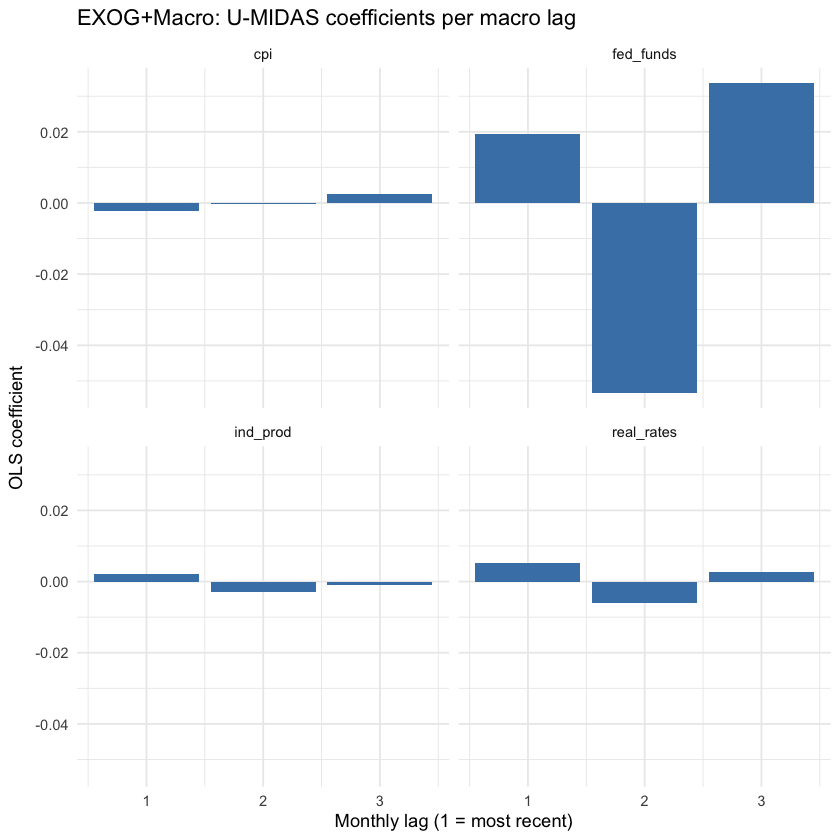

In [82]:
if (fit_em$spec == "restricted") {
  w_df <- do.call(rbind, lapply(names(fit_em$weights), function(v) {
    w <- fit_em$weights[[v]]
    data.frame(var = v, lag = seq_along(w), weight = w)
  }))
  ggplot(w_df, aes(x = lag, y = weight)) +
    geom_line(linewidth = 0.8, colour = "steelblue") +
    geom_point(size = 2, colour = "steelblue") +
    facet_wrap(~ var, ncol = 2) +
    labs(title = paste0("EXOG+Macro: fitted ", best_spec, " lag-weight profiles"),
         x = "Monthly lag (1 = most recent)", y = "Weight") +
    theme_minimal(base_size = 11)
} else {
  n_base <- length(EXOG_LAGS) + 1                          # +1 for intercept
  macro_coefs <- fit_em$coefs[(n_base + 1):length(fit_em$coefs)]
  c_df <- data.frame(name = fit_em$macro_names, coef = macro_coefs)
  c_df$var <- sub("_mlag[0-9]+$", "", c_df$name)
  c_df$lag <- as.integer(sub(".*_mlag", "", c_df$name))
  ggplot(c_df, aes(x = lag, y = coef)) +
    geom_col(fill = "steelblue") +
    facet_wrap(~ var, ncol = 2) +
    labs(title = "EXOG+Macro: U-MIDAS coefficients per macro lag",
         x = "Monthly lag (1 = most recent)", y = "OLS coefficient") +
    theme_minimal(base_size = 11)
}


## 9. Period breakdown — DA / WDA by calendar year

Best variant by WDA broken down across the standard `PERIODS` from `eval_utils`.
Same year buckets as RF / XGBoost / LSTM.

In [83]:
# Pick best non-naive variant by WDA
candidates <- metrics_df[metrics_df$model != "Naive (t-1 week)", ]
best_row   <- candidates[which.max(candidates$wda), ]
best_name  <- best_row$model
best_pred  <- all_preds[[best_name]]
cat("Best variant by WDA:", best_name, "\n")

PERIODS <- list(
  "2023 (choppy)"     = c("2023-01-01", "2023-12-31"),
  "2024 (bull start)" = c("2024-01-01", "2024-12-31"),
  "2025 (bull run)"   = c("2025-01-01", "2025-12-31"),
  "2026 (YTD)"        = c("2026-01-01", "2026-12-31"),
  "── Full test ──"   = c("2023-01-01", "2026-12-31")
)

rows <- list()
for (label in names(PERIODS)) {
  bounds <- as.Date(PERIODS[[label]])
  mask   <- dates_te >= bounds[1] & dates_te <= bounds[2]
  a <- y_te[mask]; p <- best_pred[mask]
  ok <- !is.na(a) & !is.na(p)
  if (sum(ok) < 4) next
  da_v  <- mean(sign(a[ok]) == sign(p[ok]))
  wda_v <- sum(abs(a[ok]) * (sign(a[ok]) == sign(p[ok]))) / sum(abs(a[ok]))
  rows[[label]] <- data.frame(n = sum(ok), DA = da_v, WDA = wda_v)
}
period_df <- do.call(rbind, rows)
write.csv(period_df, "../../data/processed/period_midas_weekly.csv", row.names = TRUE)
print(round(period_df, 3))

# Save winning variant predictions for cross-model DM tests in evaluation.ipynb
write.csv(
  data.frame(Date = dates_te, actual = y_te, predicted = best_pred),
  "../../data/processed/preds_midas_best_weekly.csv",
  row.names = FALSE
)
cat(sprintf("Saved winning-variant predictions: preds_midas_best_weekly.csv  (%s)\n",
            best_name))

Best variant by WDA: EXOG+GS+Sentiment 
                    n    DA   WDA
2023 (choppy)      52 0.577 0.635
2024 (bull start)  52 0.615 0.689
2025 (bull run)    52 0.558 0.569
2026 (YTD)         19 0.632 0.584
── Full test ──   175 0.589 0.618
Saved winning-variant predictions: preds_midas_best_weekly.csv  (EXOG+GS+Sentiment)


## 10. Diebold-Mariano tests

Each variant vs the `EXOG` baseline. Tests whether adding Macro (Beta-MIDAS),
sentiment, or both yields a statistically significant improvement in squared-error
loss. p < 0.05 = significant.

In [84]:
cat("Diebold-Mariano tests — each variant vs EXOG baseline\n")
cat("H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns = not significant\n")
cat(strrep("-", 90), "\n")

baseline_pred <- all_preds$"EXOG"
for (name in names(all_preds)) {
  if (name %in% c("EXOG", "Naive (t-1 week)")) next
  diebold_mariano(y_te, baseline_pred, all_preds[[name]], "EXOG", name)
}


Diebold-Mariano tests — each variant vs EXOG baseline
H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns = not significant
------------------------------------------------------------------------------------------ 
EXOG                           vs EXOG+Macro                      DM=-1.833  p=0.067  (ns)
EXOG                           vs EXOG+GS                         DM=+0.273  p=0.785  (ns)
EXOG                           vs EXOG+Reddit                     DM=-1.144  p=0.253  (ns)
EXOG                           vs EXOG+News                       DM=+0.839  p=0.402  (ns)
EXOG                           vs EXOG+Reddit+News                DM=+0.588  p=0.557  (ns)
EXOG                           vs EXOG+Macro+Sentiment            DM=-1.627  p=0.104  (ns)
EXOG                           vs EXOG+GS+Sentiment               DM=+0.645  p=0.519  (ns)
EXOG                           vs EXOG+ALL                        DM=-1.586  p=0.113  (ns)


## 11. 2026 zoom — actual vs best variant

Same 2026 view as the other weekly notebooks, using the best variant by WDA.

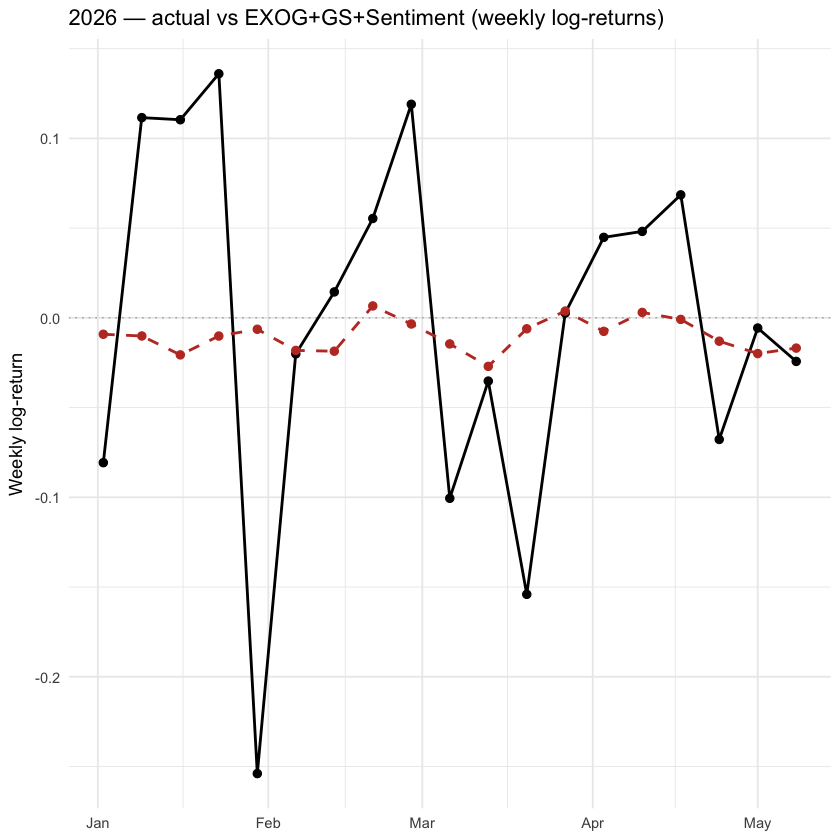

In [85]:
df26 <- data.frame(date = dates_te, actual = y_te, pred = best_pred)
df26 <- df26[df26$date >= as.Date("2026-01-01"), ]

if (nrow(df26) == 0) {
  cat("No 2026 data in test set yet.\n")
} else {
  ggplot(df26, aes(x = date)) +
    geom_hline(yintercept = 0, colour = "grey60", linewidth = 0.3, linetype = "dotted") +
    geom_line(aes(y = actual), colour = "black",  linewidth = 0.8) +
    geom_point(aes(y = actual), colour = "black", size = 2) +
    geom_line(aes(y = pred),   colour = "#c0392b", linewidth = 0.8, linetype = "dashed") +
    geom_point(aes(y = pred),  colour = "#c0392b", size = 2) +
    labs(title = paste0("2026 — actual vs ", best_name, " (weekly log-returns)"),
         x = NULL, y = "Weekly log-return") +
    theme_minimal(base_size = 11)
}
